# Análisis: La Máquina de la Dependencia (Metropolitana vs Regiones)
Análisis ampliado para entender cómo viven las personas en Regiones vs. Metropolitana, abordando temas de pobreza, ingresos, segregación espacial (tiempo de viaje), estado de la vivienda, y nivel de dependencia estatal. Los gráficos se presentan por separado para mejor visualización.

In [1]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Configuración de estilo premium minimalista
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = False

# Paletas de colores premium globales
color_subsidio = '#d94c4c' # Rojo (alarma, dependencia)
color_sin_sub = '#2b7a78'  # Verde esmeralda (autonomía)

## 1. Carga y Procesamiento de Datos
Agregamos variables extra para entender cómo viven: `ind_estado` (calidad de vivienda), `o28a_hr/min` (tiempos de viaje al trabajo), y calculamos la **Dependencia Estatal** (qué porcentaje de sus ingresos totales vienen del Estado vs Trabajo Autónomo).

In [2]:
print("Cargando datos CASEN 2024...")
df_pandas = pd.read_stata("../data/raw/casen_2024.dta", columns=[
    'id_persona', 'region', 'expr', 'yautcorh', 'ytotcorh', 'pobreza_multi', 'v15', 
    'ind_estado', 'o28a_hr', 'o28a_min'
], convert_categoricals=False)

df = pl.from_pandas(df_pandas)

# Jefes de hogar
df_hogares = df.filter(pl.col("id_persona") == 1)

# Clasificar Metropolitana vs Regiones
df_hogares = df_hogares.with_columns(
    pl.when(pl.col("region") == 13).then(pl.lit("Metropolitana")).otherwise(pl.lit("Regiones")).alias("MacroZona")
)

# Clasificar Subsidio (v15: 1 = Con subsidio, 2 = Sin subsidio)
df_analisis = df_hogares.filter(pl.col("v15").is_in([1, 2]))
df_analisis = df_analisis.with_columns(
    pl.when(pl.col("v15") == 1).then(pl.lit("Con Subsidio"))
    .when(pl.col("v15") == 2).then(pl.lit("Sin Subsidio")).alias("Subsidio")
)

# ---------------------------------------------------------
# CÁLCULOS EXTRAS PARA ENTENDER CÓMO VIVEN
# ---------------------------------------------------------

# A) Tiempo de Viaje en minutos
df_analisis = df_analisis.with_columns(
    (pl.col("o28a_hr") * 60 + pl.col("o28a_min")).alias("tiempo_viaje_min")
)
df_analisis = df_analisis.with_columns(
    pl.when(pl.col("tiempo_viaje_min") < 0).then(None).otherwise(pl.col("tiempo_viaje_min")).alias("tiempo_viaje_min")
)

# B) Dependencia Estatal (Proporción del ingreso total que NO proviene de su esfuerzo autónomo)
df_analisis = df_analisis.with_columns(
    (((pl.col("ytotcorh") - pl.col("yautcorh").fill_null(0)) / pl.col("ytotcorh")) * 100).alias("dependencia_estatal_pct")
)
df_analisis = df_analisis.with_columns(
    pl.when((pl.col("dependencia_estatal_pct") < 0) | (pl.col("dependencia_estatal_pct") > 100))
    .then(None).otherwise(pl.col("dependencia_estatal_pct")).alias("dependencia_estatal_pct")
)

print("Variables de Segregación, Estado de Vivienda, Dependencia e Ingresos calculadas.")

Cargando datos CASEN 2024...
Variables de Segregación, Estado de Vivienda, Dependencia e Ingresos calculadas.


## 2. Preparación de Agregaciones

In [3]:
# Agregaciones Generales: Pobreza, Ingresos, Viajes y Dependencia Estatal
resumen = df_analisis.group_by(["MacroZona", "Subsidio"]).agg([
    (((pl.col("pobreza_multi") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Tasa_Pobreza_%"),
    pl.col("yautcorh").median().round(0).alias("Ingreso_Mediano"),
    pl.col("tiempo_viaje_min").median().round(1).alias("Tiempo_Viaje_Mediano"),
    pl.col("dependencia_estatal_pct").median().round(1).alias("Dependencia_Mediana_%")
]).sort(["MacroZona", "Subsidio"])

df_resumen = resumen.to_pandas()
display(df_resumen)

# DataFrames Pivot para gráficos Dumbbell
df_pivot_pobreza = df_resumen.pivot(index='MacroZona', columns='Subsidio', values='Tasa_Pobreza_%').reset_index()
df_pivot_ingreso = df_resumen.pivot(index='MacroZona', columns='Subsidio', values='Ingreso_Mediano').reset_index()
df_pivot_dependencia = df_resumen.pivot(index='MacroZona', columns='Subsidio', values='Dependencia_Mediana_%').reset_index()

# ---------------------------------------------------------
# Estado de Vivienda (Calidad de Vida)
# ---------------------------------------------------------
df_estado = df_analisis.filter(pl.col("ind_estado").is_in([1, 2, 3]))
df_estado = df_estado.with_columns(
    pl.when(pl.col("ind_estado") == 1).then(pl.lit("1. Bueno"))
    .when(pl.col("ind_estado") == 2).then(pl.lit("2. Aceptable"))
    .when(pl.col("ind_estado") == 3).then(pl.lit("3. Malo")).alias("Estado_Vivienda")
)
estado_resumen = df_estado.group_by(["MacroZona", "Subsidio", "Estado_Vivienda"]).agg([
    pl.col("expr").sum().alias("Total_Hogares")
])
estado_resumen = estado_resumen.with_columns(
    (pl.col("Total_Hogares") / pl.col("Total_Hogares").sum().over(["MacroZona", "Subsidio"]) * 100).round(1).alias("Porcentaje")
)
df_estado_pivot = estado_resumen.to_pandas().pivot(index=['MacroZona', 'Subsidio'], columns='Estado_Vivienda', values='Porcentaje').fillna(0)
df_estado_pivot.index = [f"{mz}\n{sub}" for mz, sub in df_estado_pivot.index]

,MacroZona,Subsidio,Tasa_Pobreza_%,Ingreso_Mediano,Tiempo_Viaje_Mediano,Dependencia_Mediana_%
0,Metropolitana,Con Subsidio,23.6,733814.0,30.0,38.6
1,Metropolitana,Sin Subsidio,12.2,1025352.0,40.0,32.4
2,Regiones,Con Subsidio,14.7,582500.0,20.0,39.5
3,Regiones,Sin Subsidio,6.0,970788.0,20.0,30.3


## Gráfico 1: Brecha de Pobreza Multidimensional

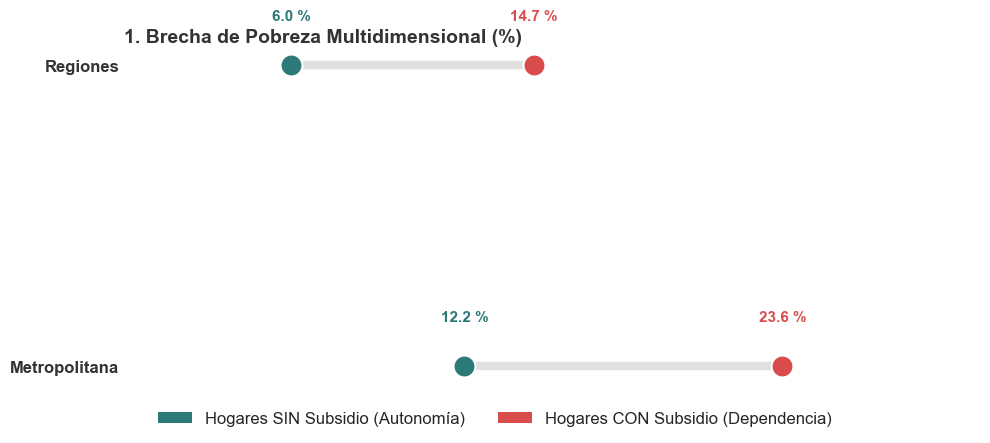

In [4]:
fig, ax1 = plt.subplots(figsize=(10, 4), dpi=100)

for i, row in df_pivot_pobreza.iterrows():
    ax1.plot([row['Con Subsidio'], row['Sin Subsidio']], [i, i], color='#e0e0e0', linewidth=6, zorder=1)
    ax1.scatter(row['Con Subsidio'], i, color=color_subsidio, s=250, zorder=2, edgecolor='white', linewidth=1.5)
    ax1.scatter(row['Sin Subsidio'], i, color=color_sin_sub, s=250, zorder=2, edgecolor='white', linewidth=1.5)
    ax1.text(row['Con Subsidio'], i + 0.15, f"{row['Con Subsidio']} %", ha='center', color=color_subsidio, fontweight='bold', fontsize=11)
    ax1.text(row['Sin Subsidio'], i + 0.15, f"{row['Sin Subsidio']} %", ha='center', color=color_sin_sub, fontweight='bold', fontsize=11)

ax1.set_yticks(range(len(df_pivot_pobreza)))
ax1.set_yticklabels(df_pivot_pobreza['MacroZona'], fontsize=12, fontweight='bold', color='#333333')
ax1.set_title('1. Brecha de Pobreza Multidimensional (%)', fontsize=14, loc='left', color='#333333', fontweight='bold')
ax1.set_xlim(0, max(df_pivot_pobreza['Con Subsidio']) * 1.3)
ax1.set_xticks([])
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_sin_sub, label='Hogares SIN Subsidio (Autonomía)'),
                   Patch(facecolor=color_subsidio, label='Hogares CON Subsidio (Dependencia)')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2, frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

## Gráfico 2: Brecha de Ingreso Autónomo Mediano

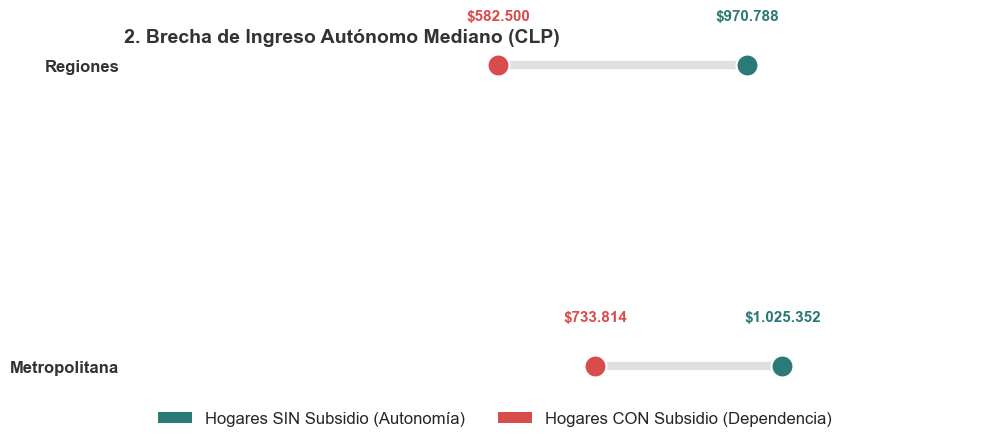

In [5]:
fig, ax2 = plt.subplots(figsize=(10, 4), dpi=100)

for i, row in df_pivot_ingreso.iterrows():
    ax2.plot([row['Con Subsidio'], row['Sin Subsidio']], [i, i], color='#e0e0e0', linewidth=6, zorder=1)
    ax2.scatter(row['Con Subsidio'], i, color=color_subsidio, s=250, zorder=2, edgecolor='white', linewidth=1.5)
    ax2.scatter(row['Sin Subsidio'], i, color=color_sin_sub, s=250, zorder=2, edgecolor='white', linewidth=1.5)
    con_fmt = f"${int(row['Con Subsidio']):,}".replace(',', '.')
    sin_fmt = f"${int(row['Sin Subsidio']):,}".replace(',', '.')
    ax2.text(row['Con Subsidio'], i + 0.15, con_fmt, ha='center', color=color_subsidio, fontweight='bold', fontsize=11)
    ax2.text(row['Sin Subsidio'], i + 0.15, sin_fmt, ha='center', color=color_sin_sub, fontweight='bold', fontsize=11)

ax2.set_yticks(range(len(df_pivot_ingreso)))
ax2.set_yticklabels(df_pivot_ingreso['MacroZona'], fontsize=12, fontweight='bold', color='#333333')
ax2.set_title('2. Brecha de Ingreso Autónomo Mediano (CLP)', fontsize=14, loc='left', color='#333333', fontweight='bold')
ax2.set_xlim(0, max(df_pivot_ingreso['Sin Subsidio']) * 1.3)
ax2.set_xticks([])
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2, frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

## Gráfico 3: Nivel de Dependencia Estatal (Proporción del Ingreso)
¿Qué porcentaje del dinero con el que cuenta el hogar mensualmente viene directamente del Estado y no del trabajo propio? Esto ilustra directamente el concepto de "La Máquina de la Dependencia".

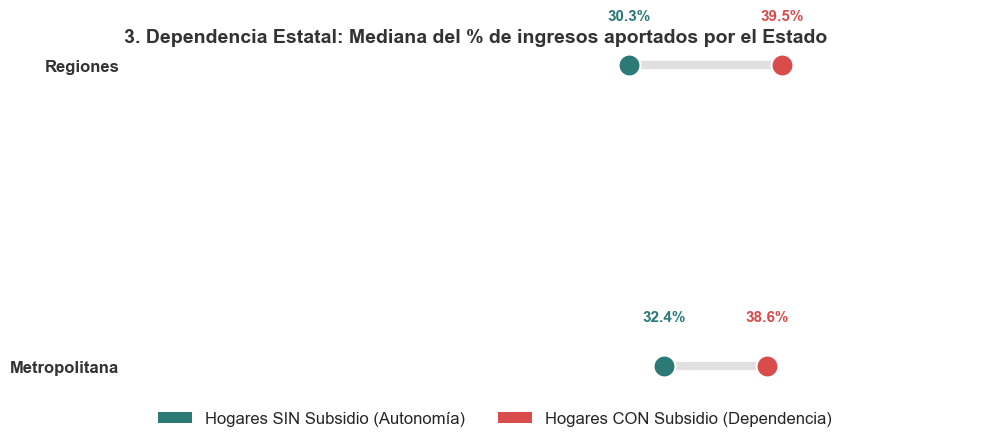

In [6]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

for i, row in df_pivot_dependencia.iterrows():
    ax.plot([row['Con Subsidio'], row['Sin Subsidio']], [i, i], color='#e0e0e0', linewidth=6, zorder=1)
    ax.scatter(row['Con Subsidio'], i, color=color_subsidio, s=250, zorder=2, edgecolor='white', linewidth=1.5)
    ax.scatter(row['Sin Subsidio'], i, color=color_sin_sub, s=250, zorder=2, edgecolor='white', linewidth=1.5)
    
    ax.text(row['Con Subsidio'], i + 0.15, f"{row['Con Subsidio']}%", ha='center', color=color_subsidio, fontweight='bold', fontsize=11)
    ax.text(row['Sin Subsidio'], i + 0.15, f"{row['Sin Subsidio']}%", ha='center', color=color_sin_sub, fontweight='bold', fontsize=11)

ax.set_yticks(range(len(df_pivot_dependencia)))
ax.set_yticklabels(df_pivot_dependencia['MacroZona'], fontsize=12, fontweight='bold', color='#333333')
ax.set_title('3. Dependencia Estatal: Mediana del % de ingresos aportados por el Estado', fontsize=14, loc='left', color='#333333', fontweight='bold')
ax.set_xlim(0, max(df_pivot_dependencia['Con Subsidio']) * 1.3)
ax.set_xticks([])
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2, frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

## Gráfico 4: Segregación Espacial (Tiempos de Viaje con Escala Secuencial)
Refleja el impacto en cómo viven: las viviendas con subsidio, especialmente en la Metropolitana, tienden a relegar a las familias a las periferias, aumentando fuertemente el tiempo diario destinado al transporte.

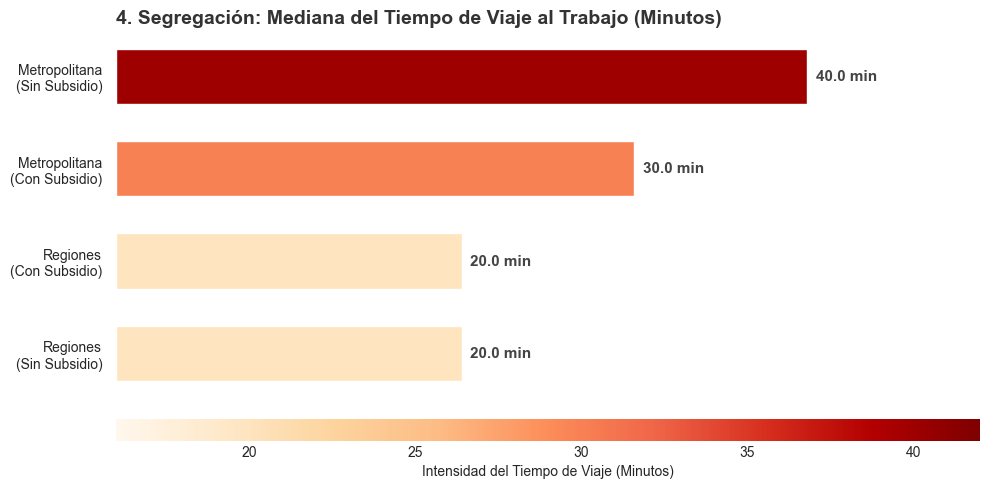

In [7]:
fig, ax3 = plt.subplots(figsize=(10, 5), dpi=100)

df_viaje = df_resumen.sort_values(by="Tiempo_Viaje_Mediano")
df_viaje['Grupo'] = df_viaje['MacroZona'] + "\n(" + df_viaje['Subsidio'] + ")"

# ESCALA SECUENCIAL (OrRd)
norm = plt.Normalize(df_viaje["Tiempo_Viaje_Mediano"].min() * 0.8, df_viaje["Tiempo_Viaje_Mediano"].max() * 1.05)
sm = plt.cm.ScalarMappable(cmap="OrRd", norm=norm)
colors = [sm.to_rgba(val) for val in df_viaje["Tiempo_Viaje_Mediano"]]

bars = ax3.barh(df_viaje['Grupo'], df_viaje['Tiempo_Viaje_Mediano'], color=colors, height=0.6, edgecolor='white', linewidth=1)
ax3.set_title('4. Segregación: Mediana del Tiempo de Viaje al Trabajo (Minutos)', fontsize=14, loc='left', color='#333333', fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax3.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f} min', 
             ha='left', va='center', fontweight='bold', color='#444444', fontsize=11)
    
ax3.set_xlim(0, df_viaje['Tiempo_Viaje_Mediano'].max() * 1.25)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_xticks([])
ax3.tick_params(axis='y', labelsize=10, pad=10)

cbar3 = fig.colorbar(sm, ax=ax3, orientation='horizontal', fraction=0.08, pad=0.05, aspect=40)
cbar3.set_label('Intensidad del Tiempo de Viaje (Minutos)', fontsize=10)
cbar3.outline.set_visible(False)

plt.tight_layout()
plt.show()

## Gráfico 5: Calidad de Vida e Infraestructura (Estado de Conservación)
Usando la variable `ind_estado` de CASEN. Un Heatmap secuencial evidencia la proporción de viviendas en estado Malo y Aceptable, demostrando las brechas en la calidad material de la vida diaria.

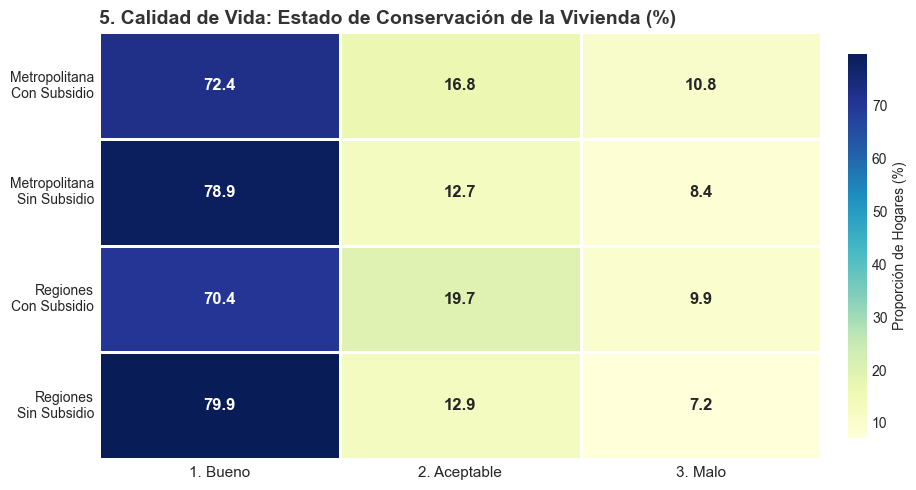

In [8]:
fig, ax4 = plt.subplots(figsize=(10, 5), dpi=100)

sns.heatmap(df_estado_pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax4,
            linewidths=2, linecolor='white', 
            cbar_kws={'label': 'Proporción de Hogares (%)', 'pad': 0.03, 'shrink': 0.9},
            annot_kws={"size": 12, "weight": "bold"})

ax4.set_title('5. Calidad de Vida: Estado de Conservación de la Vivienda (%)', fontsize=14, loc='left', color='#333333', fontweight='bold')
ax4.set_ylabel('')
ax4.set_xlabel('')
ax4.tick_params(axis='y', rotation=0, labelsize=10)
ax4.tick_params(axis='x', labelsize=11, pad=5)

plt.tight_layout()
plt.show()